# Stack Overflow Data Analysis 2025

The Stack Overflow Annual Developer Survey is the most comprehensive census of software developers worldwide\. Every year, tens of thousands of professionals and students share insights into their coding habits, the tools they use, and their professional lives\. This problem set utilizes the 2025 Survey Results, a rich, high\-dimensional dataset that reflects the latest shifts in the technology landscape, including the rapid adoption of AI and evolving compensation models\.

As a data scientist, the ability to transform a raw, "noisy" dataset into clear, actionable insights is a foundational skill\. Through this assignment, you will navigate the entire data science pipeline—from cleaning and preprocessing to advanced exploratory analysis\. You will specifically investigate the United States developer market, exploring how variables like education, experience, and the use of Python correlate with job satisfaction and salary\.

### Learning Objectives


By completing this problem set, students will be able to:

- Implement Data Wrangling Pipelines: Practice loading large\-scale CSV files and performing essential preprocessing steps such as filtering, handling missing values \(NaNs\), and data type casting\.

- Execute Targeted Exploratory Data Analysis \(EDA\): Segment data based on specific geographical and professional criteria \(e\.g\., U\.S\.\-based employed developers\) to identify localized trends\.

- Perform Feature Engineering: Derive new categorical and boolean features from complex string data \(e\.g\., identifying Python developers within a multi\-value column\)\.

- Analyze Statistical Correlations: Quantify the relationship between continuous variables, such as years of coding experience and annual compensation, to understand career progression\.

- Visualize Complex Relationships: Create distribution plots and categorical comparisons to communicate insights regarding job satisfaction and the "Python Premium" in the current job market\.

- Synthesize Actionable Insights: Move beyond descriptive statistics to identify the primary drivers of high\-income roles within the modern tech ecosystem\.

### Part 1: Data Cleaning & Wrangling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


1\. Load & Inspect: Load the dataset and display the first 5 rows and the column summary\.

Hint: Use pd\.read\_csv\(\), \.head\(\), and \.info\(\)\.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Attempt to read the CSV with a fallback for encoding issues
# The error indicates invalid UTF-8 bytes; we'll try common encodings and report which succeeds.
encodings_to_try = [
    'utf-8',            # default
    'utf-8-sig',        # handles BOM
    'latin-1',          # very permissive; will not error on undecodable bytes
    'cp1252'            # common Windows encoding
]

last_error = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv('survey_results_public_2025_v1.csv', encoding=enc)
        print(f"Loaded CSV successfully using encoding: {enc}")
        break
    except UnicodeDecodeError as e:
        print(f"Failed with encoding {enc}: {e}")
        last_error = e
else:
    # As a very robust fallback, use latin-1 with errors='replace' via Python's open
    try:
        with open('survey_results_public_2025_v1.csv', 'r', encoding='latin-1', errors='replace') as f:
            df = pd.read_csv(f)
        print("Loaded CSV using latin-1 with errors='replace' fallback.")
    except Exception as e:
        raise RuntimeError(f"Unable to load CSV due to encoding issues. Last Unicode error: {last_error}; Fallback error: {e}")

# Basic inspection per the assignment instructions
print(df.head())
print(df.info())

Failed with encoding utf-8: 'utf-8' codec can't decode byte 0xf4 in position 1: invalid continuation byte
Failed with encoding utf-8-sig: 'utf-8' codec can't decode byte 0xf4 in position 216234: invalid continuation byte
Loaded CSV successfully using encoding: latin-1
  ResponseId                      MainBranch              Age  \
0          1  I am a developer by profession  25-34 years old   
1          2  I am a developer by profession  25-34 years old   
2          3  I am a developer by profession  35-44 years old   
3          4  I am a developer by profession  35-44 years old   
4          5  I am a developer by profession  35-44 years old   

                                          EdLevel  \
0  Masters degree (M.A., M.S., M.Eng., MBA, etc.)   
1             Associate degree (A.A., A.S., etc.)   
2     Bachelors degree (B.A., B.S., B.Eng., etc.)   
3     Bachelors degree (B.A., B.S., B.Eng., etc.)   
4  Masters degree (M.A., M.S., M.Eng., MBA, etc.)   

                     

2\. Filter by Country: Create a new DataFrame containing only respondents from the 'United States of America'\.

Hint: Use boolean indexing: df\[df\['Country'\] == '\.\.\.'\]\.  remember need to use \.copy\(\) attribute to create a new dataframe

In [3]:
## create a new df for USA respondents only

df_usa = df[df['Country'] == 'United States of America'].copy()

print(df_usa.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7226 entries, 21 to 49097
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              7226 non-null   object 
 1   MainBranch              7226 non-null   object 
 2   Age                     7226 non-null   object 
 3   EdLevel                 7203 non-null   object 
 4   Employment              7226 non-null   object 
 5   WorkExp                 6785 non-null   float64
 6   YearsCode               7121 non-null   float64
 7   DevType                 7226 non-null   object 
 8   OrgSize                 5888 non-null   object 
 9   RemoteWork              5855 non-null   object 
 10  Industry                6290 non-null   object 
 11  Country                 7226 non-null   object 
 12  LanguageHaveWorkedWith  6649 non-null   object 
 13  AIThreat                6982 non-null   object 
 14  AISelect                6931 non-null   obj

3\. Filter by Employment: Narrow the data further to include only those where Employment is 'Employed'\.

Hint: Use the == operator on the 'Employment' column\.

In [4]:
## create a new dataframe with only employed developers
#df_employed = df[df['Employment'] == 'Employed'].copy()

df_employed = df_usa[df_usa['Employment'] == 'Employed'].copy()

df_employed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5408 entries, 21 to 49097
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              5408 non-null   object 
 1   MainBranch              5408 non-null   object 
 2   Age                     5408 non-null   object 
 3   EdLevel                 5399 non-null   object 
 4   Employment              5408 non-null   object 
 5   WorkExp                 5312 non-null   float64
 6   YearsCode               5355 non-null   float64
 7   DevType                 5408 non-null   object 
 8   OrgSize                 5391 non-null   object 
 9   RemoteWork              5365 non-null   object 
 10  Industry                5379 non-null   object 
 11  Country                 5408 non-null   object 
 12  LanguageHaveWorkedWith  5068 non-null   object 
 13  AIThreat                5396 non-null   object 
 14  AISelect                5214 non-null   obj

4\. Drop Missing Salaries: Remove all rows where the ConvertedCompYearly column is null\.

Hint: Use \.dropna\(subset=\['ConvertedCompYearly'\]\)\.

In [5]:
## create a new dataframe without null values in the convertedcompyearly column

df_employed = df_employed.dropna(subset=['ConvertedCompYearly']).copy()

df_employed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4529 entries, 22 to 49015
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              4529 non-null   object 
 1   MainBranch              4529 non-null   object 
 2   Age                     4529 non-null   object 
 3   EdLevel                 4524 non-null   object 
 4   Employment              4529 non-null   object 
 5   WorkExp                 4493 non-null   float64
 6   YearsCode               4519 non-null   float64
 7   DevType                 4529 non-null   object 
 8   OrgSize                 4525 non-null   object 
 9   RemoteWork              4512 non-null   object 
 10  Industry                4525 non-null   object 
 11  Country                 4529 non-null   object 
 12  LanguageHaveWorkedWith  4318 non-null   object 
 13  AIThreat                4529 non-null   object 
 14  AISelect                4425 non-null   obj

5\. Clean Satisfaction Scores: Fill missing values in the JobSat column with the median satisfaction of the group\.

Hint: Use \.fillna\(\) and \.median\(\)\.

In [6]:
#  Check JobSat before cleaning
print("Missing before:", df_employed['JobSat'].isna().sum())
print("Median JobSat:", df_employed['JobSat'].median())

# Fill missing JobSat with the median
df_employed['JobSat'] = df_employed['JobSat'].fillna(df_employed['JobSat'].median())

# Confirm no missing values remain
print("Missing after:", df_employed['JobSat'].isna().sum())

Missing before: 781
Median JobSat: 8.0
Missing after: 0


6\. Convert to Numeric: Ensure YearsCode and WorkExp are numeric\. Convert any non\-numeric entries to NaN\.

Hint: Use pd\.to\_numeric\(series, errors='coerce'\)\.   // this error='coerce' option will convert any non\-numeric to NaN

In [7]:
## Convert YearsCode and WorkExp to numeric, coercing errors to NaN

df_employed['YearsCode'] = pd.to_numeric(df_employed['YearsCode'], errors='coerce')
df_employed['WorkExp'] = pd.to_numeric(df_employed['WorkExp'], errors='coerce')

# Verify dtypes and check how many NaNs were introduced (or already existed)
print(df_employed[['YearsCode', 'WorkExp']].dtypes)
print()
print("YearsCode missing:", df_employed['YearsCode'].isna().sum())
print("WorkExp missing:  ", df_employed['WorkExp'].isna().sum())

YearsCode    float64
WorkExp      float64
dtype: object

YearsCode missing: 10
WorkExp missing:   36


7\. Engineer Python Column: Create a boolean column is\_python\_dev that is True if 'Python' is in the LanguageHaveWorkedWith string\.

Hint: Use \.str\.contains\('Python', na=False\)\.

In [8]:
## Create boolean column: True if respondent has worked with Python
df_employed['is_python_dev'] = df_employed['LanguageHaveWorkedWith'].str.contains('Python', na=False)

# Verify the result
print(df_employed['is_python_dev'].value_counts())
print()
print(df_employed[['LanguageHaveWorkedWith', 'is_python_dev']].head(10))

is_python_dev
True     2703
False    1826
Name: count, dtype: int64

                               LanguageHaveWorkedWith  is_python_dev
22       C#;C++;JavaScript;Python;Visual Basic (.Net)           True
29  Bash/Shell (all shells);C;C#;C++;Java;JavaScri...          False
31          Elixir;HTML/CSS;JavaScript;SQL;TypeScript          False
33                                      C#;Python;SQL           True
37  Ada;Assembly;Bash/Shell (all shells);C;C#;C++;...           True
39                       HTML/CSS;JavaScript;Ruby;SQL          False
40  HTML/CSS;Java;JavaScript;PHP;PowerShell;Python...           True
41              HTML/CSS;JavaScript;Python;TypeScript           True
42  Bash/Shell (all shells);C;C#;C++;HTML/CSS;Java...           True
53  Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...          False


8\. Simplify Education: Group the EdLevel column into three simple categories: 'Undergrad', 'Graduate', and 'Other'\.

Hint: Define a function and use \.apply\(\)\.

In [9]:
## Here is the function written for you.

def simplify_ed(level):
    if pd.isna(level): return 'Other'
    level = level.lower()
    if 'bachelor' in level: return 'Undergrad'
    if 'master' in level or 'doctoral' in level or 'professional' in level: return 'Graduate'
    return 'Other'

# Apply the function row-by-row across the EdLevel column
df_employed['EdLevel'] = df_employed['EdLevel'].apply(simplify_ed)

# Verify the result
print(df_employed['EdLevel'].value_counts())



EdLevel
Undergrad    2529
Graduate     1163
Other         837
Name: count, dtype: int64


### Part 2: Demographic & Experience Exploration


9\. Age Distribution \(Bar Chart\): Visualize the count of developers in each age bracket using a bar chart\.

Hint: Use \.value\_counts\(\)\.sort\_index\(\)\.plot\(kind='bar'\)\.

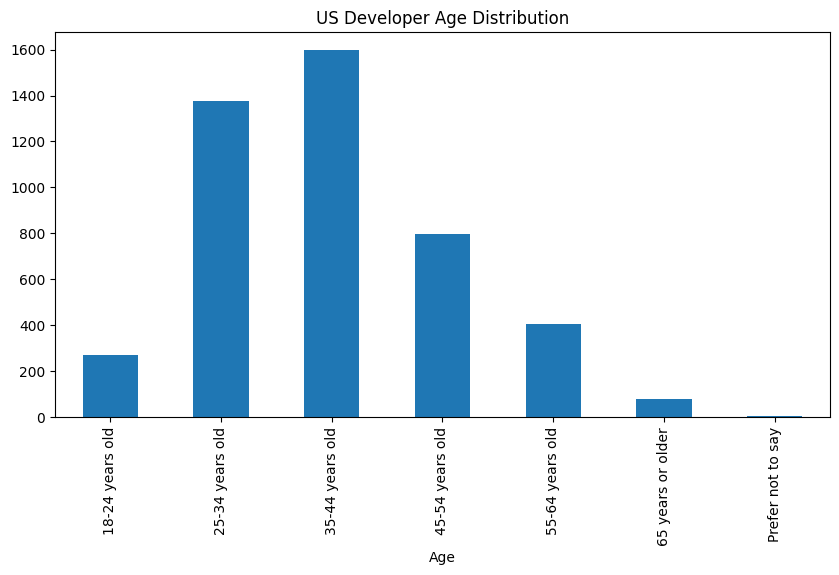

In [10]:
plt.figure(figsize=(10, 5))

## plot the Age values as a bar chart
df_employed['Age'].value_counts().sort_index().plot(kind='bar')

plt.title('US Developer Age Distribution')
plt.show()

10\. Experience Summary: Calculate the mean and median YearsCode for the US market\.

Hint:  Use\.mean\(\) and \.median\(\)\.

In [11]:
## Get the Mean and Median of YearsCode

mean_exp = df_employed['YearsCode'].mean()
median_exp = df_employed['YearsCode'].median()

print(f"Mean Experience: {mean_exp:.2f} years")
print(f"Median Experience: {median_exp} years")

Mean Experience: 20.30 years
Median Experience: 18.0 years


11\. Experience vs\. Pay \(Correlation\): Calculate the Pearson correlation between YearsCode and ConvertedCompYearly\.

Hint: Use the \.corr\(\) method\.

In [12]:
## Pearson correlation between YearsCode and ConvertedCompYearly

correlation_years = df_employed[['YearsCode','ConvertedCompYearly']].corr()

#get the signle value from the correlation matrix
corr_years = correlation_years.loc['YearsCode', 'ConvertedCompYearly']

print(f"Correlation (YearsCode vs Salary): {corr_years:.4f}")

Correlation (YearsCode vs Salary): 0.1380


12\. Work Experience Comparison: Calculate the correlation between WorkExp and salary\. Compare it to the result from Task 11\.

Hint: Use \.corr\(\) on 'WorkExp' and 'ConvertedCompYearly'\.

In [13]:
## Pearson correlation between YearsCode and ConvertedCompYearly

correlation_workexp = df_employed[['WorkExp','ConvertedCompYearly']].corr()

#get the single value from the correlation matrix
corr_work = correlation_workexp.loc['WorkExp', 'ConvertedCompYearly']

print(f"Correlation (WorkExp vs Salary): {corr_work:.4f}")

Correlation (WorkExp vs Salary): 0.1014


The correlation between work experience in years and compensation is very similar to that between compensation and coding experience in years\. 

### Part 3: Compensation & Industry Insights


13\. Salary Distribution \(Histogram\): Create a histogram of ConvertedCompYearly with a KDE line\. Limit the x\-axis to $500k\.

Hint: Use sns\.histplot\(\) and plt\.xlim\(\)\.

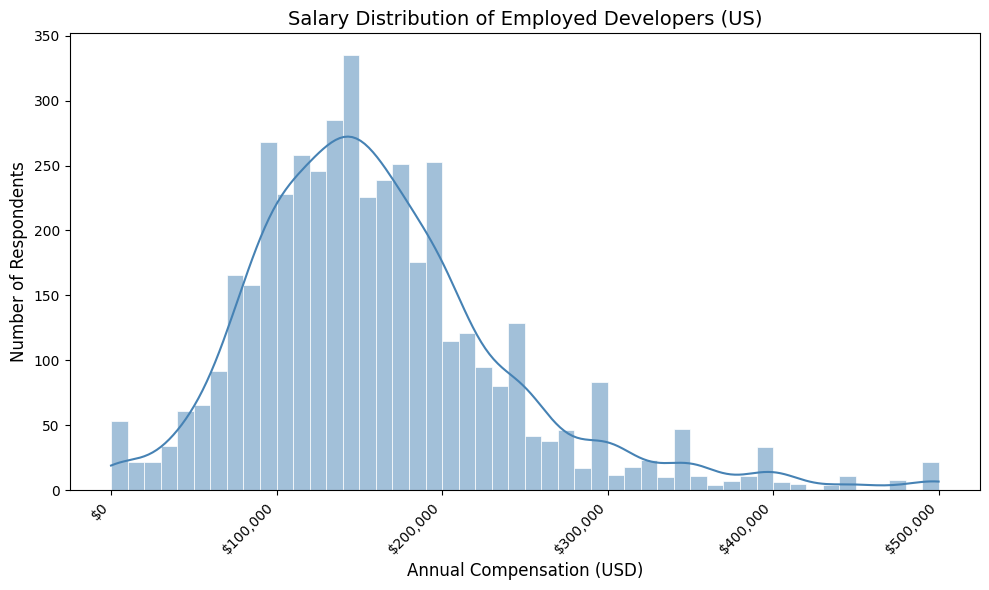

In [14]:
# Drop NaN and filter to <= 500k
salary_data = df_employed['ConvertedCompYearly'].dropna()

#remove data above 500k otherwise the curve will look flat if you just limit the axes.
salary_data = salary_data[salary_data <= 500000]

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=salary_data,
    kde=True,
    bins=50,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Salary Distribution of Employed Developers (US)', fontsize=14)
ax.set_xlabel('Annual Compensation (USD)', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

14\. The Python Premium: Compare the median salary of Python developers vs\. non\-Python developers\. How much difference?

Hint: Group by is\_python\_dev and calculate the median\.

In [15]:

##  Group by is_python_dev and calculate median salary
python_premium = (df_employed
                  .groupby('is_python_dev')['ConvertedCompYearly']
                  .median())

print(python_premium)
print()

py_med = python_premium[True]
non_py_med = python_premium[False]


print(f"Python Median Salary: ${py_med:,.2f}")
print(f"Non-Python Median Salary: ${non_py_med:,.2f}")
print(f"The 'Python Premium' is: ${py_med - non_py_med:,.2f}")

is_python_dev
False    148000.0
True     157000.0
Name: ConvertedCompYearly, dtype: float64

Python Median Salary: $157,000.00
Non-Python Median Salary: $148,000.00
The 'Python Premium' is: $9,000.00


15\. Remote Work & Pay \(Boxplot\): Create a boxplot showing salary distributions for different RemoteWork types\.

Hint: Use sns\.boxplot\(\) and sort categories by median\.

Rows before filter: 4529
Rows after filter:  4438
Rows removed:       91


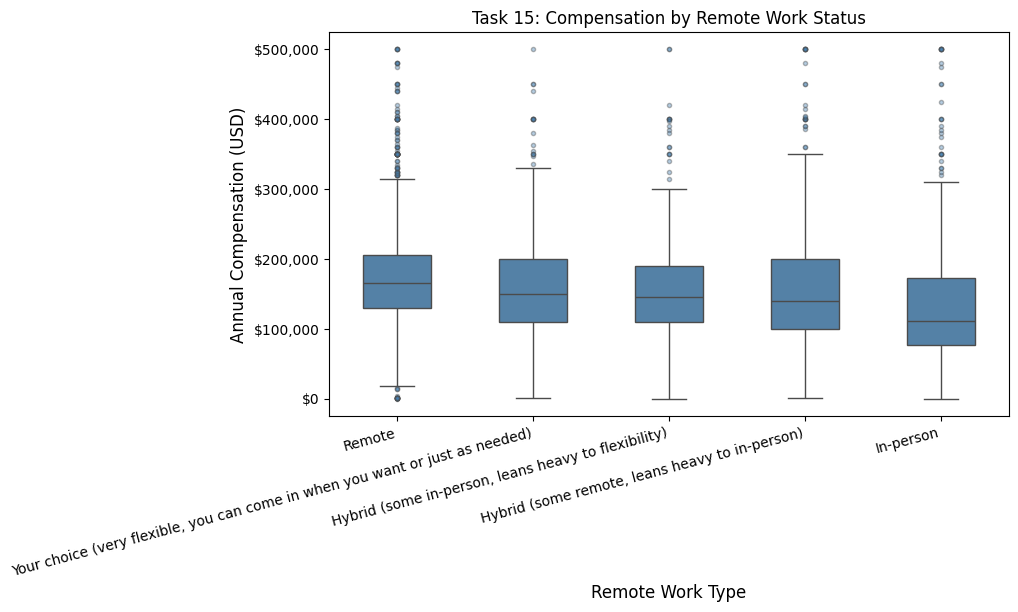

In [16]:

# Filter out salaries above $500k before plotting
df_plot = df_employed[df_employed['ConvertedCompYearly'] <= 500000].copy()

print(f"Rows before filter: {len(df_employed)}")
print(f"Rows after filter:  {len(df_plot)}")
print(f"Rows removed:       {len(df_employed) - len(df_plot)}")

# Calculate median salary per RemoteWork category for sorting
remote_order = (df_plot
                .groupby('RemoteWork')['ConvertedCompYearly']
                .median()
                .sort_values(ascending=False)
                .index)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x='RemoteWork',
    y='ConvertedCompYearly',
    order=remote_order,
    color='steelblue',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='steelblue',
                    markersize=3, alpha=0.4),
    ax=ax
)


ax.set_xlabel('Remote Work Type', fontsize=12)
ax.set_ylabel('Annual Compensation (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('remote_work_salary.png', dpi=150)



plt.title('Task 15: Compensation by Remote Work Status')
plt.show()

16\. Job Satisfaction vs\. Pay \(Boxplot\): Visualize if higher salaries correlate with higher JobSat scores using a boxplot\.

Hint: Put JobSat on the x\-axis and ConvertedCompYearly on the y\-axis\.

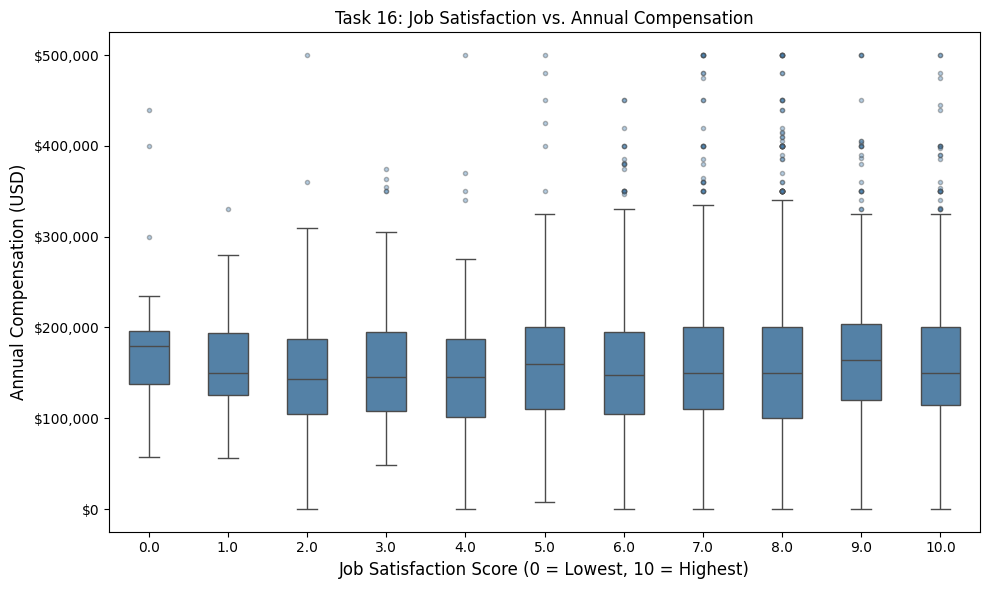

In [17]:
# Filter salaries to <= $500k (consistent with previous step)
df_plot = df_employed[df_employed['ConvertedCompYearly'] <= 500000].copy()

# Sort JobSat scores in ascending order on x-axis (0 → 10)
jobsat_order = sorted(df_plot['JobSat'].dropna().unique())

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x='JobSat',
    y='ConvertedCompYearly',
    order=jobsat_order,
    color='steelblue',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='steelblue',
                    markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Salary Distribution by Job Satisfaction Score (US)', fontsize=14)
ax.set_xlabel('Job Satisfaction Score (0 = Lowest, 10 = Highest)', fontsize=12)
ax.set_ylabel('Annual Compensation (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('jobsat_salary.png', dpi=150)

plt.title('Task 16: Job Satisfaction vs. Annual Compensation')
plt.show()

16\. Job Satisfaction vs\. Pay \(Boxplot\): Visualize if higher salaries correlate with higher JobSat scores using a boxplot\.

Hint: Put JobSat on the x\-axis and ConvertedCompYearly on the y\-axis\.

17\. Top 10 Paying Industries \(Bar Chart\): Identify and visualize the 10 industries with the highest median pay\.

Hint: Group by Industry, calculate median, sort, and use head\(10\)\.

/tmp/ipykernel_2628/2483293137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


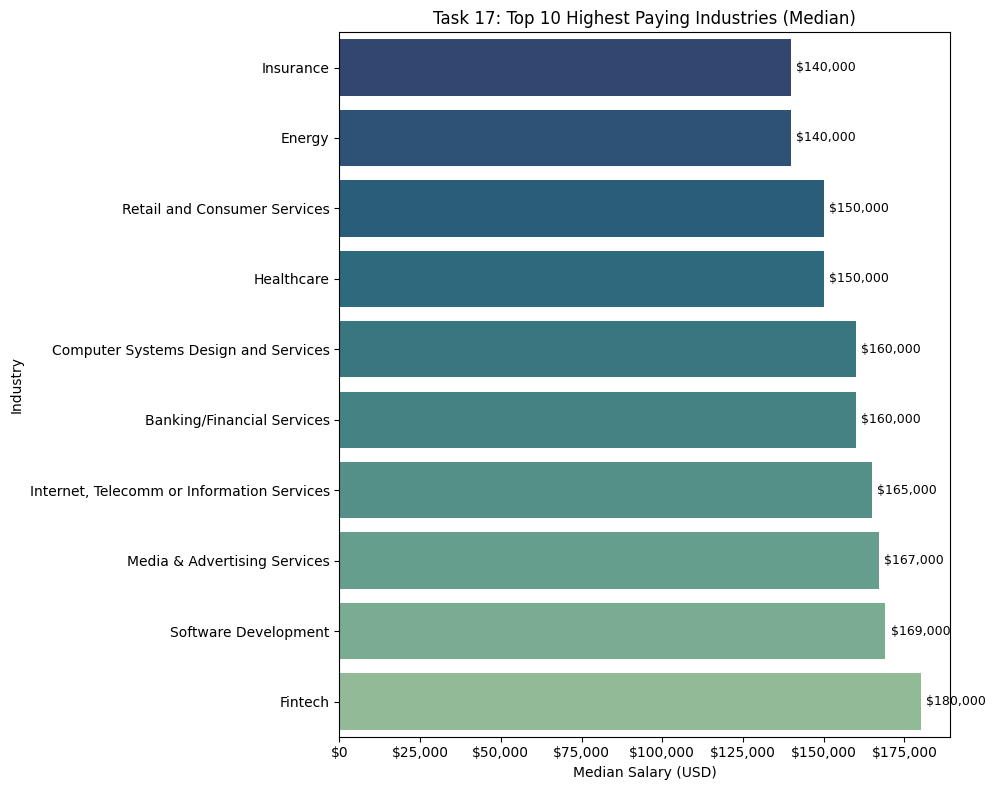

In [18]:
# Filter salaries to <= $500k 
df_plot = df_employed[df_employed['ConvertedCompYearly'] <= 500000].copy()

# Calculate median salary per industry, sort descending, take top 10
top10_industries = (
    df_plot
    .groupby('Industry')['ConvertedCompYearly']
    .median()
    .sort_values(ascending=False)  
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    x=top10_industries.values,
    y=top10_industries.index,
    palette='crest',
    ax=ax
)

# Add value labels
for i, val in enumerate(top10_industries.values):
    ax.text(val * 1.01, i, f'${val:,.0f}', va='center', fontsize=9)

ax.set_ylabel('Industry')
ax.set_xlabel('Median Salary (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title('Task 17: Top 10 Highest Paying Industries (Median)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_industries_salary.png', dpi=150)
plt.show()

18\. Company Size Impact: Calculate the median salary based on OrgSize\. Does company size matter?

Hint: Use \.groupby\('OrgSize'\)\['ConvertedCompYearly'\]\.median\(\)\.

In [19]:
# Calculate median salary by OrgSize
org_med = (df_employed
           .groupby('OrgSize')['ConvertedCompYearly']
           .median()
           .sort_values(ascending=False))

print("\nMedian Salary by Organization Size:\n", org_med)




Median Salary by Organization Size:
 OrgSize
10,000 or more employees                              171500.0
5,000 to 9,999 employees                              160000.0
100 to 499 employees                                  154000.0
1,000 to 4,999 employees                              150000.0
500 to 999 employees                                  146349.5
20 to 99 employees                                    145000.0
I dont know                                           130000.0
Less than 20 employees                                125000.0
Just me - I am a freelancer, sole proprietor, etc.     75000.0
Name: ConvertedCompYearly, dtype: float64


Bigger companies have higher median salaries according to this survey and the trend could be due to higher economies of scale or more structured pay bands\. 

19\. Identify Salary Outliers: Find the percentage of respondents earning more than 3 standard deviations above the mean salary\.

Hint: Calculate mean \+ \(3 \* std\) and then compute the % of the filtered cases divided by total number of cases\.

In [20]:

##  Calculate mean and standard deviation of salary
salary_mean = df_employed['ConvertedCompYearly'].mean()
salary_std  = df_employed['ConvertedCompYearly'].std()

# Define the outlier threshold: mean + 3 standard deviations
threshold = salary_mean + (3 * salary_std)

# Count outliers and total non-null respondents
n_outliers = (df_employed['ConvertedCompYearly'] > threshold).sum()
n_total    = df_employed['ConvertedCompYearly'].notna().sum()

# Calculate percentage
outlier_pct = (n_outliers / n_total) * 100

print(f"\nPercentage of extreme salary outliers: {outlier_pct:.2f}%")


Percentage of extreme salary outliers: 0.82%


20\. The $150k Threshold: What percentage of Python developers earn more than $150,000 compared to non\-Python developers?

Hint: Create a boolean 'high\_earner' column and use \.mean\(\) per group\.

In [21]:

# Create boolean high_earner column
df_employed['high_earner'] = df_employed['ConvertedCompYearly'] > 150000

# Calculate percentage of high earners per group
high_earner_stats = (df_employed
                     .groupby('is_python_dev')['high_earner']
                     .mean() * 100)

print(f"High Earner % (Python Developers): {high_earner_stats[True]:.2f}%")
print(f"High Earner % (Non-Python Developers): {high_earner_stats[False]:.2f}%")

High Earner % (Python Developers): 51.91%
High Earner % (Non-Python Developers): 45.56%


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2472ef9a-1ef0-4e06-890e-c72f0fef586c' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>